# Bénin Insights — Analyse exploratoire GDELT

**Période étudiée** : janvier 2025 — avril 2026  
**Source** : GDELT

## Séquences

1. Qualité et périmètre des données  
2. Dynamique temporelle de la couverture  
3. Types d'événements dominants  
4. Acteurs, sources et géographie  
5. Anomalies et signaux clés


## Séquence 1 — Qualité et périmètre des données


On prépare l’environnement et on pointe le fichier source.

Le notebook peut maintenant lire le dataset nettoyé.


In [33]:
from pathlib import Path
from urllib.parse import urlparse

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

project_root = Path.cwd()
if not (project_root / "data").exists():
    project_root = project_root.parent

data_path = project_root / "data/processed/gdelt_benin_clean.csv"
if not data_path.exists():
    raise FileNotFoundError(f"Fichier introuvable: {data_path}")


On nettoie les colonnes utiles et on prépare les variables de temps et de source.

Le corpus est prêt pour l’analyse descriptive.


In [2]:
df = pd.read_csv(data_path).copy()
df["date"] = pd.to_datetime(df["date"], errors="coerce")
for col in ["NumArticles", "AvgTone", "GoldsteinScale", "ActionGeo_Lat", "ActionGeo_Long"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

for col in ["Actor1Name", "Actor2Name", "event_label", "ActionGeo_FullName", "SOURCEURL"]:
    if col in df.columns:
        df[col] = df[col].fillna("Inconnu")

df["year_month"] = df["date"].dt.to_period("M").astype(str)
df["source_domain"] = df["SOURCEURL"].apply(lambda x: urlparse(x).netloc.replace("www.", "") if isinstance(x, str) else "inconnu")

print(f"Lignes : {len(df):,}")
print(f"Colonnes : {len(df.columns)}")
df.head(3)


Lignes : 5,089
Colonnes : 24


,Actor1Name,Actor1CountryCode,Actor2Name,Actor2CountryCode,EventCode,EventBaseCode,EventRootCode,GoldsteinScale,NumArticles,AvgTone,ActionGeo_FullName,ActionGeo_CountryCode,ActionGeo_Lat,ActionGeo_Long,SOURCEURL,date,annee,mois,mois_label,semaine,event_label,sentiment,year_month,source_domain
0,ZIMBABWE,ZWE,Inconnu,Inconnu,125,125,12,-5.0,8,-1.923077,Benin,BN,9.50000,2.25000,https://eahelqesa.com/news/%D8%AA%D8%A7%D8%B1%...,2026-01-01,2026,1,Jan 2026,1,Rejet / Refus,négatif,2026-01,eahelqesa.com
1,SIERRA LEONE,SLE,Inconnu,Inconnu,81,81,8,5.0,10,3.793627,"Ouidah, Atlantique, Benin",BN,6.36307,2.08506,https://www.blackenterprise.com/minding-our-ow...,2026-01-31,2026,1,Jan 2026,5,Accord / Coopération,positif,2026-01,blackenterprise.com
2,NIGERIAN,NGA,Inconnu,Inconnu,874,87,8,10.0,10,0.000000,Benin,BN,9.50000,2.25000,https://africalog.com/benin-retrait-des-troupe...,2026-02-01,2026,2,Feb 2026,5,Accord / Coopération,neutre,2026-02,africalog.com


### 1.1 Structure du corpus


Cette table pose la structure générale du corpus.

une vue rapide des types, manquants et cardinalités.


In [3]:
summary = pd.DataFrame({
    "colonne": df.columns,
    "type": df.dtypes.astype(str).values,
    "valeurs_manquantes": df.isna().sum().values,
    "taux_manquant_pct": (df.isna().mean().mul(100).round(2)).values,
    "valeurs_uniques": [df[c].nunique(dropna=True) for c in df.columns],
})
summary


,colonne,type,valeurs_manquantes,taux_manquant_pct,valeurs_uniques
0,Actor1Name,object,0,0.0,469
1,Actor1CountryCode,object,0,0.0,88
2,Actor2Name,object,0,0.0,390
3,Actor2CountryCode,object,0,0.0,80
4,EventCode,int64,0,0.0,129
5,EventBaseCode,int64,0,0.0,102
6,EventRootCode,int64,0,0.0,19
7,GoldsteinScale,float64,0,0.0,40
8,NumArticles,int64,0,0.0,17
9,AvgTone,float64,0,0.0,2274


### 1.2 Qualité minimale des données


On vérifie les indicateurs minimaux de qualité.

une lecture rapide du volume, des doublons et des champs sensibles.


In [4]:
quality_kpis = pd.DataFrame({
    "indicateur": [
        "Lignes totales",
        "Doublons exacts",
        "Dates manquantes",
        "AvgTone manquant",
        "Goldstein manquant",
        "NumArticles manquant",
    ],
    "valeur": [
        len(df),
        int(df.duplicated().sum()),
        int(df["date"].isna().sum()),
        int(df["AvgTone"].isna().sum()),
        int(df["GoldsteinScale"].isna().sum()),
        int(df["NumArticles"].isna().sum()),
    ],
})
quality_kpis


,indicateur,valeur
0,Lignes totales,5089
1,Doublons exacts,0
2,Dates manquantes,0
3,AvgTone manquant,0
4,Goldstein manquant,0
5,NumArticles manquant,0


Le graphique isole les colonnes les plus incomplètes.

les colonnes fragiles apparaissent immédiatement.


In [5]:
missing = (
    df.isna().mean().mul(100).sort_values(ascending=False).reset_index()
    .rename(columns={"index": "colonne", 0: "taux_manquant_pct"})
)
missing = missing[missing["taux_manquant_pct"] > 0]

if not missing.empty:
    ax = sns.barplot(data=missing, y="colonne", x="taux_manquant_pct", palette="mako")
    ax.set_title("Taux de valeurs manquantes par colonne")
    ax.set_xlabel("% de valeurs manquantes")
    ax.set_ylabel("")
    plt.show()
else:
    print("Aucune colonne significativement manquante.")


Aucune colonne significativement manquante.


### 1.3 Périmètre temporel observé


On mesure la couverture réelle de chaque mois observé.

repérage des mois complets et partiels.


In [6]:
coverage = (
    df.groupby("year_month")
    .agg(
        events=("date", "size"),
        first_day=("date", "min"),
        last_day=("date", "max"),
    )
    .reset_index()
)
coverage["calendar_start"] = pd.to_datetime(coverage["year_month"] + "-01")
coverage["calendar_end"] = coverage["calendar_start"] + pd.offsets.MonthEnd(0)
coverage["observed_days"] = (coverage["last_day"] - coverage["first_day"]).dt.days + 1
coverage["calendar_days"] = (coverage["calendar_end"] - coverage["calendar_start"]).dt.days + 1
coverage["is_partial_month"] = (
    (coverage["first_day"] > coverage["calendar_start"]) |
    (coverage["last_day"] < coverage["calendar_end"])
)
coverage


,year_month,events,first_day,last_day,calendar_start,calendar_end,observed_days,calendar_days,is_partial_month
0,2025-01,705,2025-01-01,2025-01-31,2025-01-01,2025-01-31,31,31,False
1,2025-02,293,2025-02-02,2025-02-27,2025-02-01,2025-02-28,26,28,True
2,2025-03,322,2025-03-01,2025-03-31,2025-03-01,2025-03-31,31,31,False
3,2025-04,171,2025-04-01,2025-04-29,2025-04-01,2025-04-30,29,30,True
4,2025-05,219,2025-05-01,2025-05-31,2025-05-01,2025-05-31,31,31,False
5,2025-06,75,2025-06-01,2025-06-09,2025-06-01,2025-06-30,9,30,True
6,2025-07,25,2025-07-19,2025-07-27,2025-07-01,2025-07-31,9,31,True
7,2025-10,57,2025-10-05,2025-10-20,2025-10-01,2025-10-31,16,31,True
8,2025-11,73,2025-11-07,2025-11-30,2025-11-01,2025-11-30,24,30,True
9,2025-12,173,2025-12-07,2025-12-31,2025-12-01,2025-12-31,25,31,True


Le volume mensuel est comparé en tenant compte des mois partiels.

une première lecture fiable de la couverture temporelle.


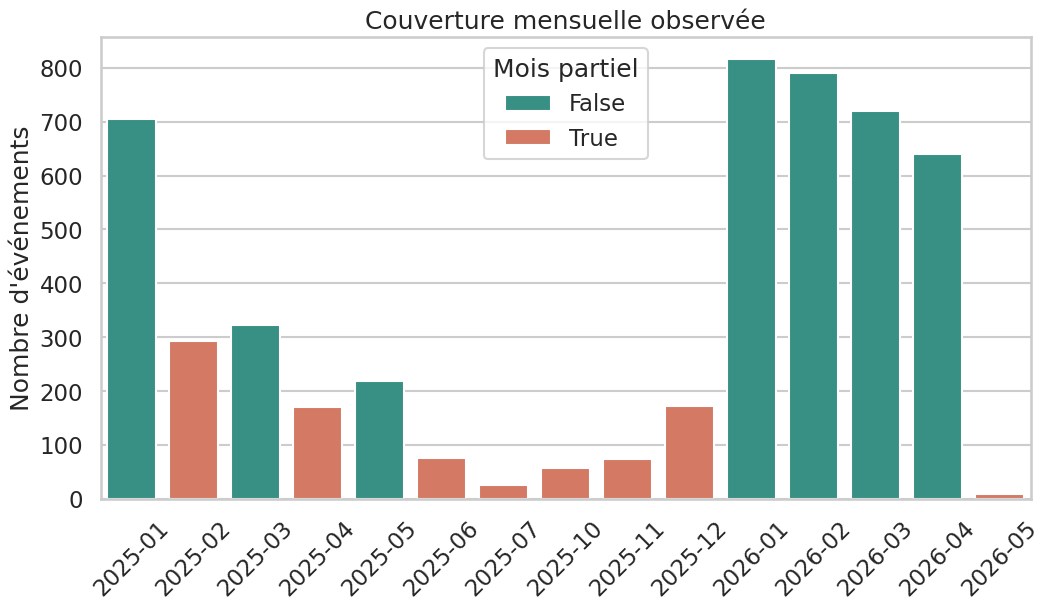

In [7]:
ax = sns.barplot(
    data=coverage,
    x="year_month",
    y="events",
    hue="is_partial_month",
    palette={False: "#2a9d8f", True: "#e76f51"},
)
ax.set_title("Couverture mensuelle observée")
ax.set_xlabel("")
ax.set_ylabel("Nombre d'événements")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Mois partiel")
plt.show()


## Séquence 2 — Dynamique temporelle de la couverture


### 2.1 Volume mensuel des événements


On passe maintenant à une vue mensuelle du corpus.

une table de travail pour le volume, le ton et Goldstein.


In [8]:
monthly = (
    df.groupby("year_month")
    .agg(
        events=("date", "size"),
        avg_tone=("AvgTone", "mean"),
        avg_goldstein=("GoldsteinScale", "mean"),
        avg_articles=("NumArticles", "mean"),
    )
    .reset_index()
)
monthly["mom_change_pct"] = monthly["events"].pct_change().mul(100)
monthly


,year_month,events,avg_tone,avg_goldstein,avg_articles,mom_change_pct
0,2025-01,705,-1.106617,0.580426,7.043972,NaN
1,2025-02,293,-1.380411,0.869625,7.641638,-58.439716
2,2025-03,322,-1.162040,0.808075,7.618012,9.897611
3,2025-04,171,-0.121355,1.680117,6.935673,-46.894410
4,2025-05,219,-0.570265,1.433333,7.525114,28.070175
5,2025-06,75,-0.419531,1.332000,7.040000,-65.753425
6,2025-07,25,-0.575261,1.392000,6.640000,-66.666667
7,2025-10,57,-0.656073,1.138596,6.684211,128.000000
8,2025-11,73,-0.881445,-0.041096,7.958904,28.070175
9,2025-12,173,-2.773172,-0.758382,7.884393,136.986301


La courbe suit l’évolution du volume d’événements par mois.

identification visuelle des pics, creux et ruptures.


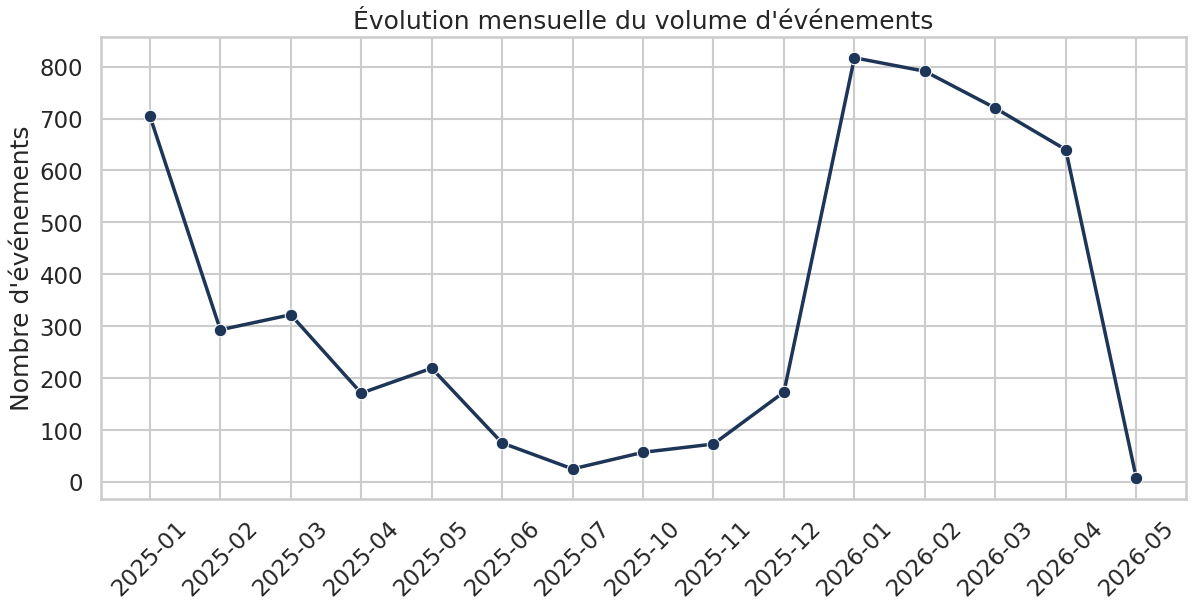

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=monthly, x="year_month", y="events", marker="o", linewidth=2.5, color="#1d3557", ax=ax)
ax.set_title("Évolution mensuelle du volume d'événements")
ax.set_xlabel("")
ax.set_ylabel("Nombre d'événements")
ax.tick_params(axis="x", rotation=45)
plt.show()


### 2.2 Variations mensuelles du volume


On observe maintenant les variations mensuelles du volume.

lecture plus nette des accélérations et replis.


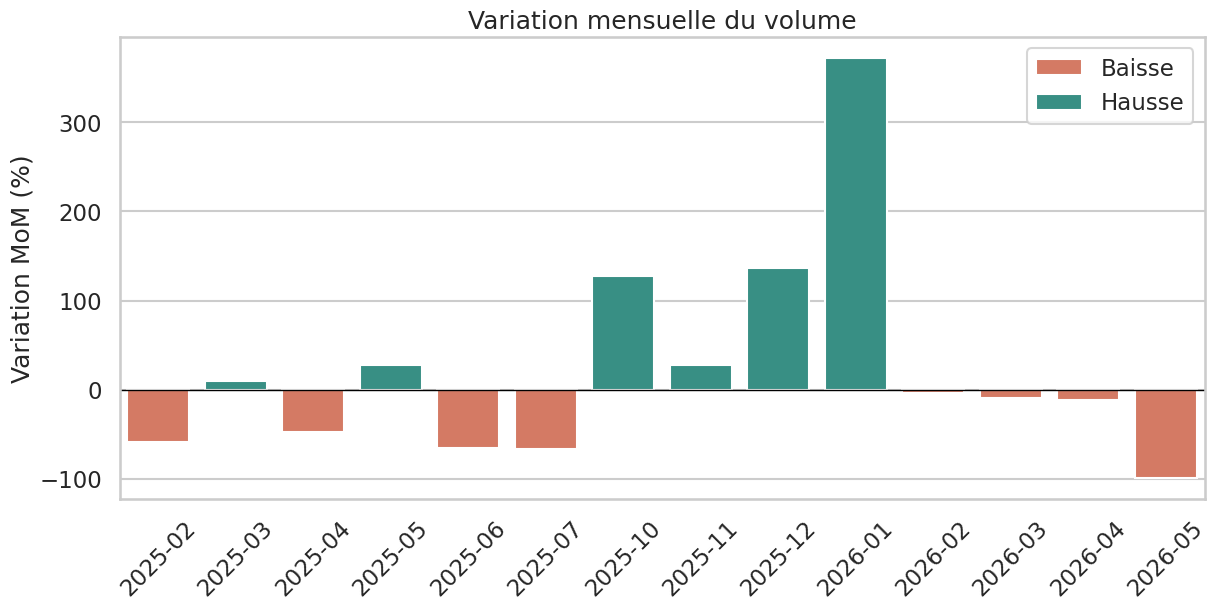

In [10]:
monthly_delta = monthly.dropna(subset=["mom_change_pct"]).copy()
monthly_delta["direction"] = np.where(monthly_delta["mom_change_pct"] >= 0, "Hausse", "Baisse")

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(
    data=monthly_delta,
    x="year_month",
    y="mom_change_pct",
    hue="direction",
    palette={"Hausse": "#2a9d8f", "Baisse": "#e76f51"},
    dodge=False,
    ax=ax,
)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Variation mensuelle du volume")
ax.set_xlabel("")
ax.set_ylabel("Variation MoM (%)")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="")
plt.show()


### 2.3 Intensité article par événement


On regarde ici l’intensité de couverture par événement.

distribution centrale et présence d’extrêmes sur NumArticles.


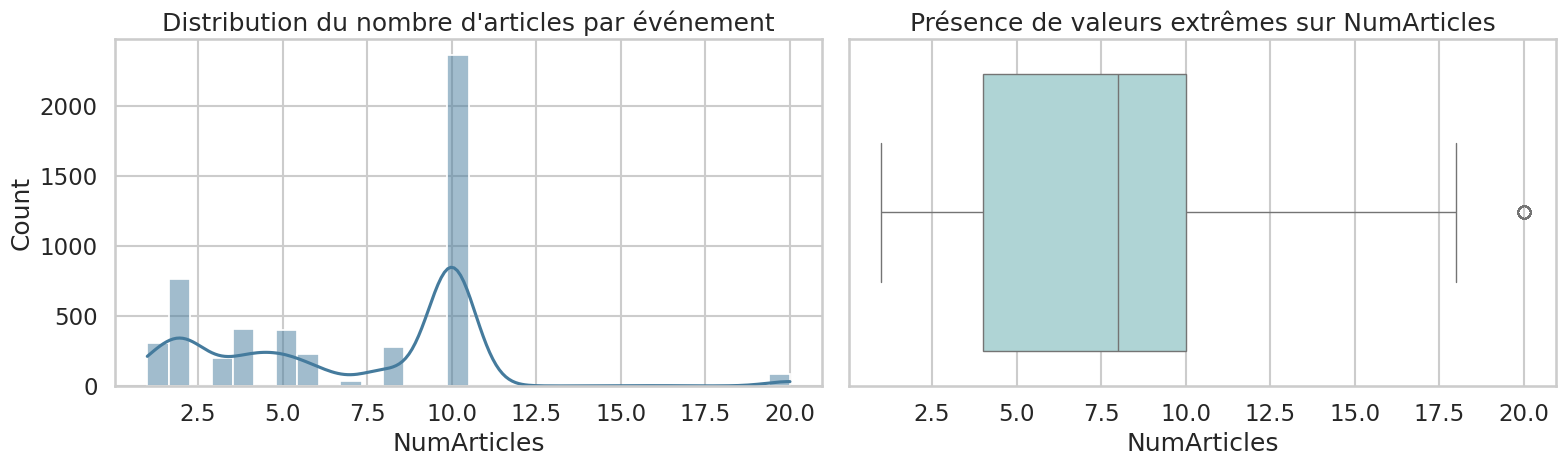

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df["NumArticles"].dropna(), bins=30, kde=True, color="#457b9d", ax=axes[0])
axes[0].set_title("Distribution du nombre d'articles par événement")
axes[0].set_xlabel("NumArticles")

sns.boxplot(data=df, x="NumArticles", color="#a8dadc", ax=axes[1])
axes[1].set_title("Présence de valeurs extrêmes sur NumArticles")
axes[1].set_xlabel("NumArticles")
plt.tight_layout()
plt.show()


## Séquence 3 — Climat médiatique


### 3.1 Tonalité moyenne dans le temps


La série suit le ton moyen mois par mois.

lecture directe du climat médiatique dans le temps.


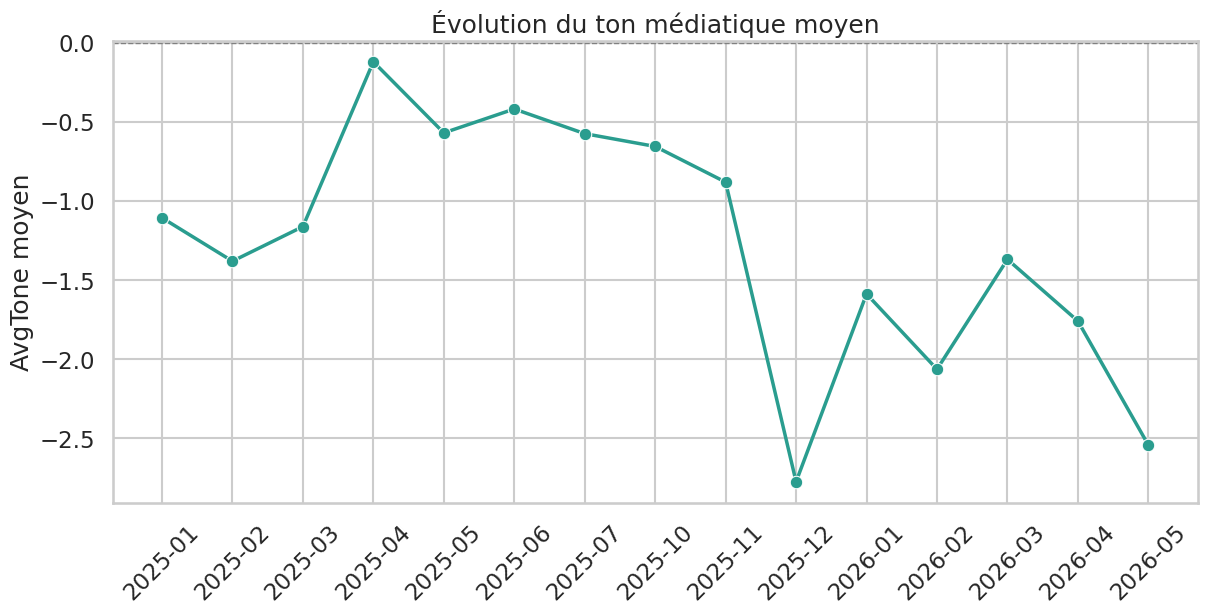

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=monthly, x="year_month", y="avg_tone", marker="o", linewidth=2.5, color="#2a9d8f", ax=ax)
ax.axhline(0, linestyle="--", color="gray", linewidth=1)
ax.set_title("Évolution du ton médiatique moyen")
ax.set_xlabel("")
ax.set_ylabel("AvgTone moyen")
ax.tick_params(axis="x", rotation=45)
plt.show()


### 3.2 Distribution du ton


Les événements sont regroupés par niveaux de tonalité.

répartition entre tonalités négatives, neutres et positives.


/tmp/ipykernel_54225/2560425278.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="tone_bucket", order=tone_order, palette="viridis")


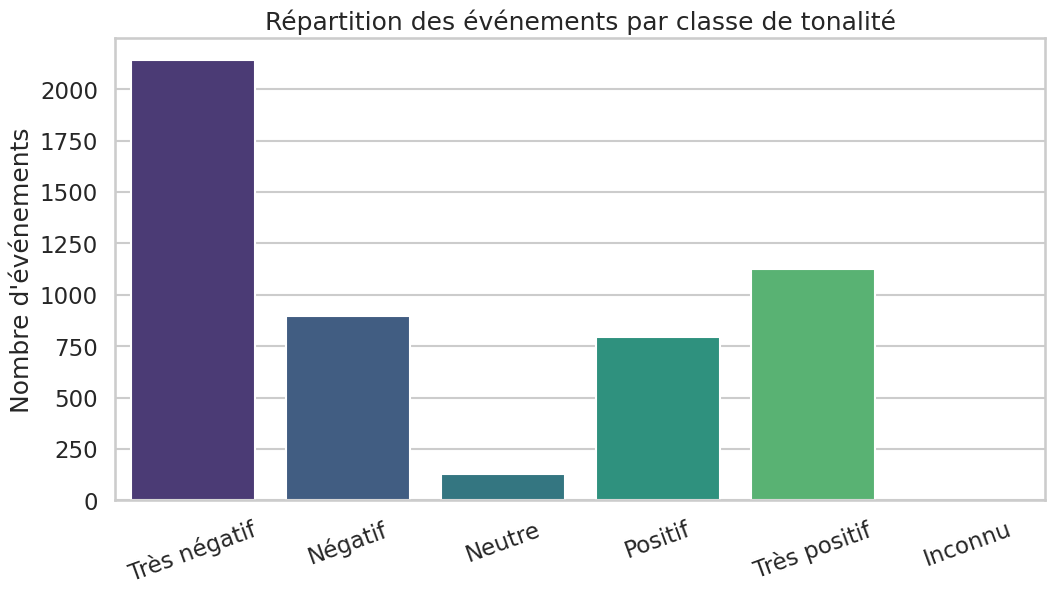

In [13]:
def tone_bucket(value):
    if pd.isna(value):
        return "Inconnu"
    if value <= -2:
        return "Très négatif"
    if value < 0:
        return "Négatif"
    if value == 0:
        return "Neutre"
    if value < 2:
        return "Positif"
    return "Très positif"


df["tone_bucket"] = df["AvgTone"].apply(tone_bucket)
tone_order = ["Très négatif", "Négatif", "Neutre", "Positif", "Très positif", "Inconnu"]

ax = sns.countplot(data=df, x="tone_bucket", order=tone_order, palette="viridis")
ax.set_title("Répartition des événements par classe de tonalité")
ax.set_xlabel("")
ax.set_ylabel("Nombre d'événements")
ax.tick_params(axis="x", rotation=20)
plt.show()


### 3.3 Lecture Goldstein


La série suit le score Goldstein moyen dans le temps.

lecture complémentaire du niveau de tension ou de coopération.


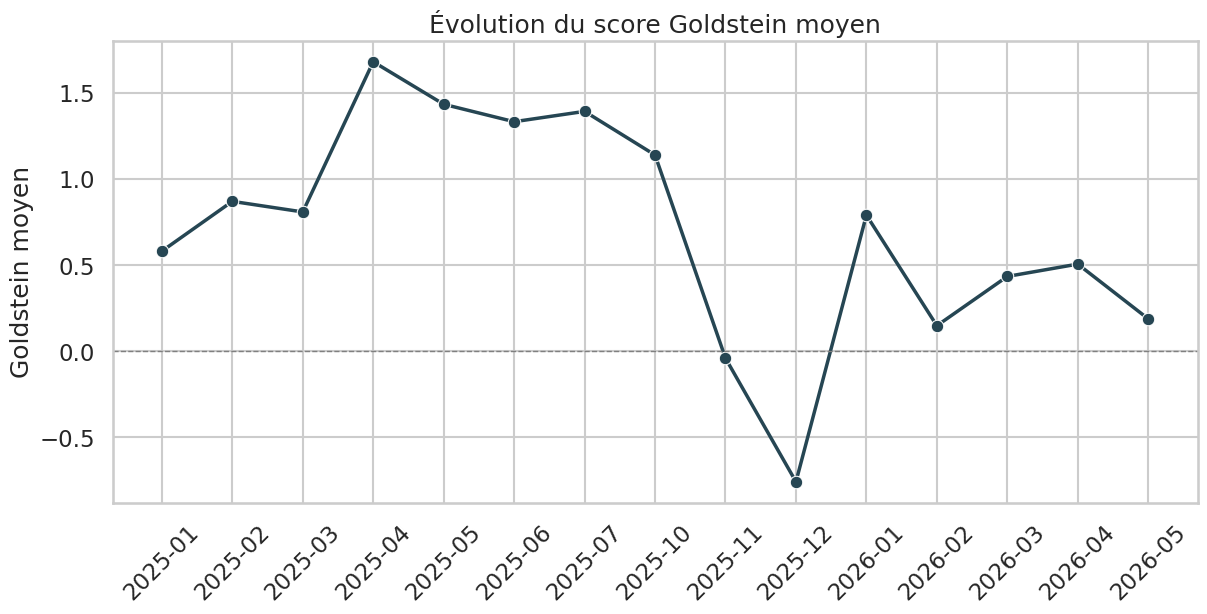

In [14]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=monthly, x="year_month", y="avg_goldstein", marker="o", linewidth=2.5, color="#264653", ax=ax)
ax.axhline(0, linestyle="--", color="gray", linewidth=1)
ax.set_title("Évolution du score Goldstein moyen")
ax.set_xlabel("")
ax.set_ylabel("Goldstein moyen")
ax.tick_params(axis="x", rotation=45)
plt.show()


On compare ici Goldstein et AvgTone au niveau événement.

aperçu du lien entre conflit diplomatique et tonalité médiatique.


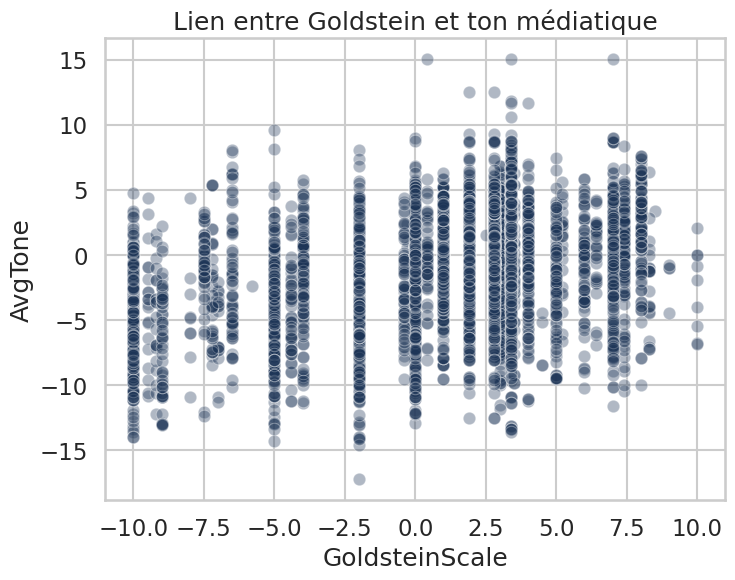

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=df, x="GoldsteinScale", y="AvgTone", alpha=0.35, color="#1d3557", ax=ax)
ax.set_title("Lien entre Goldstein et ton médiatique")
ax.set_xlabel("GoldsteinScale")
ax.set_ylabel("AvgTone")
plt.show()


## Séquence 4 — Types d'événements dominants


### 4.1 Distribution des types


On compte les types d’événements les plus fréquents.

une hiérarchie brute des catégories dominantes.


In [16]:
type_counts = (
    df["event_label"]
    .value_counts()
    .rename_axis("event_label")
    .reset_index(name="events")
)
type_counts.head(12)


,event_label,events
0,Consultation,1358
1,Déclaration publique,713
2,Engagement diplomatique,611
3,Appel / Demande,340
4,Désapprobation,325
5,Violence de masse,297
6,Coercition,218
7,Accord / Coopération,187
8,Coopération,178
9,Aide / Assistance,175


Le graphique met en avant les principaux types d’événements.

lecture rapide des catégories qui structurent le corpus.


/tmp/ipykernel_54225/1558575288.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=type_counts.head(10), y="event_label", x="events", palette="crest", ax=ax)


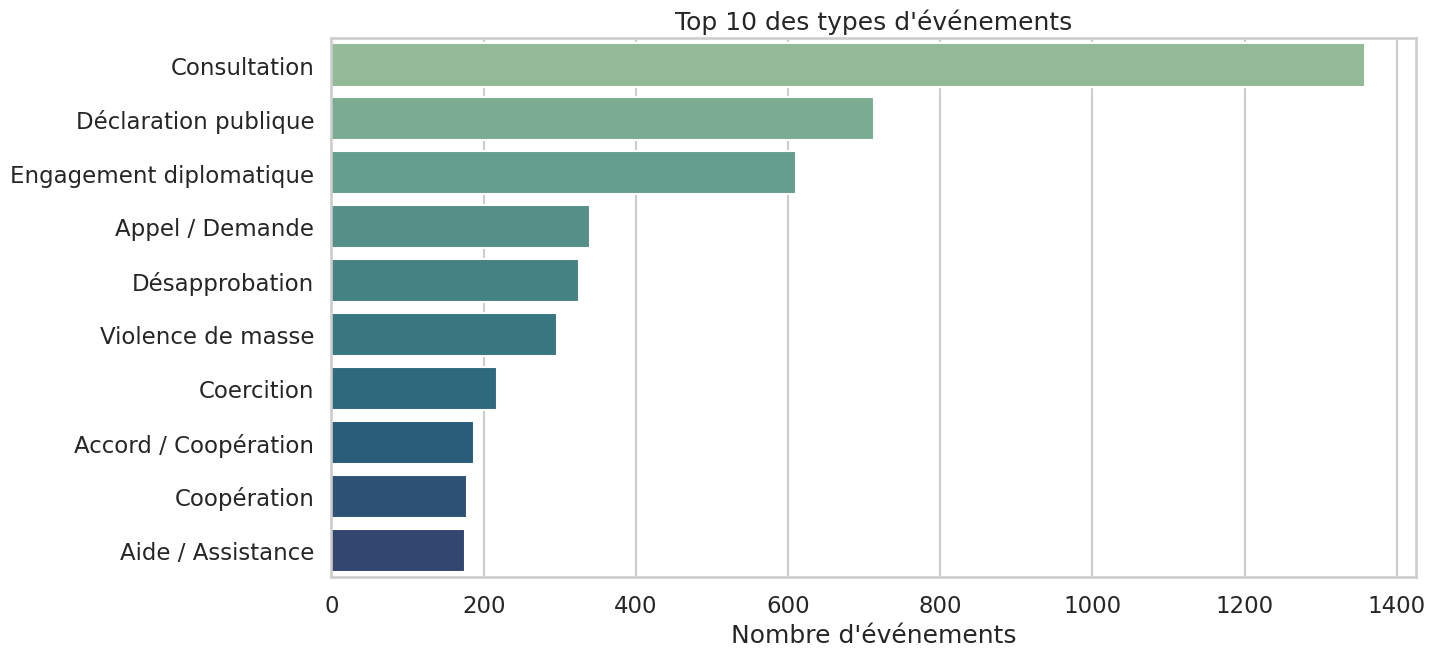

In [17]:
fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(data=type_counts.head(10), y="event_label", x="events", palette="crest", ax=ax)
ax.set_title("Top 10 des types d'événements")
ax.set_xlabel("Nombre d'événements")
ax.set_ylabel("")
plt.show()


La répartition peut aussi se lire comme un partage du corpus entre quelques catégories dominantes.

Le diagramme circulaire montre le poids cumulé des cinq principaux types et du reste du corpus.


In [ ]:
pie_data = type_counts.head(5).copy()
others = pd.DataFrame([{"event_label": "Autres", "events": type_counts.iloc[5:]["events"].sum()}])
pie_data = pd.concat([pie_data, others], ignore_index=True)

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(
    pie_data["events"],
    labels=pie_data["event_label"],
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    wedgeprops={"edgecolor": "white", "linewidth": 1},
)
ax.set_title("Poids des principaux types d'événements")
plt.show()


### 4.2 Types dominants dans le temps


On suit les principaux types dans le temps.

identification des bascules de structure selon les mois.


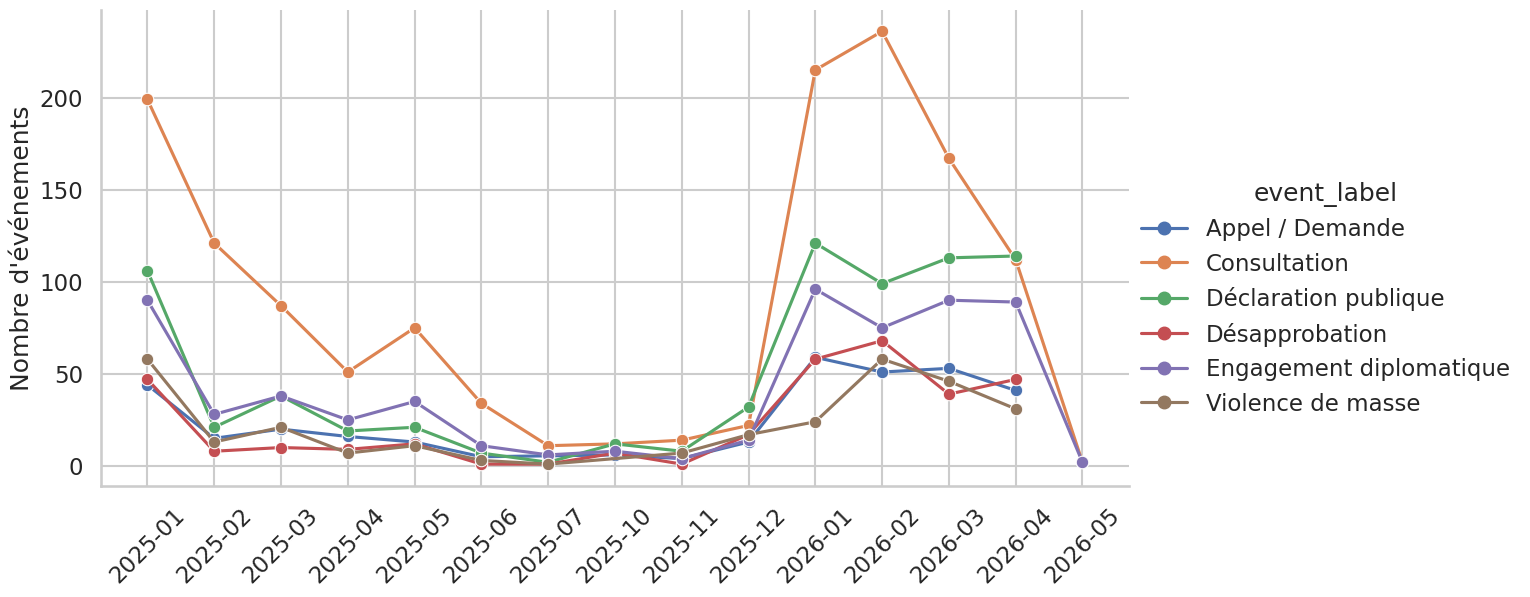

In [18]:
type_month = (
    df.groupby(["year_month", "event_label"]).size().reset_index(name="events")
)
top_types = type_counts.head(6)["event_label"].tolist()
type_month_top = type_month[type_month["event_label"].isin(top_types)].copy()

a = sns.relplot(
    data=type_month_top,
    x="year_month",
    y="events",
    hue="event_label",
    kind="line",
    marker="o",
    height=6,
    aspect=2,
)
a.set_titles("")
a.set_xlabels("")
a.set_ylabels("Nombre d'événements")
for ax in a.axes.flat:
    ax.tick_params(axis="x", rotation=45)
plt.show()


### 4.3 Heatmap types × mois


La heatmap croise types d’événements et mois.

intensités relatives par type et par période.


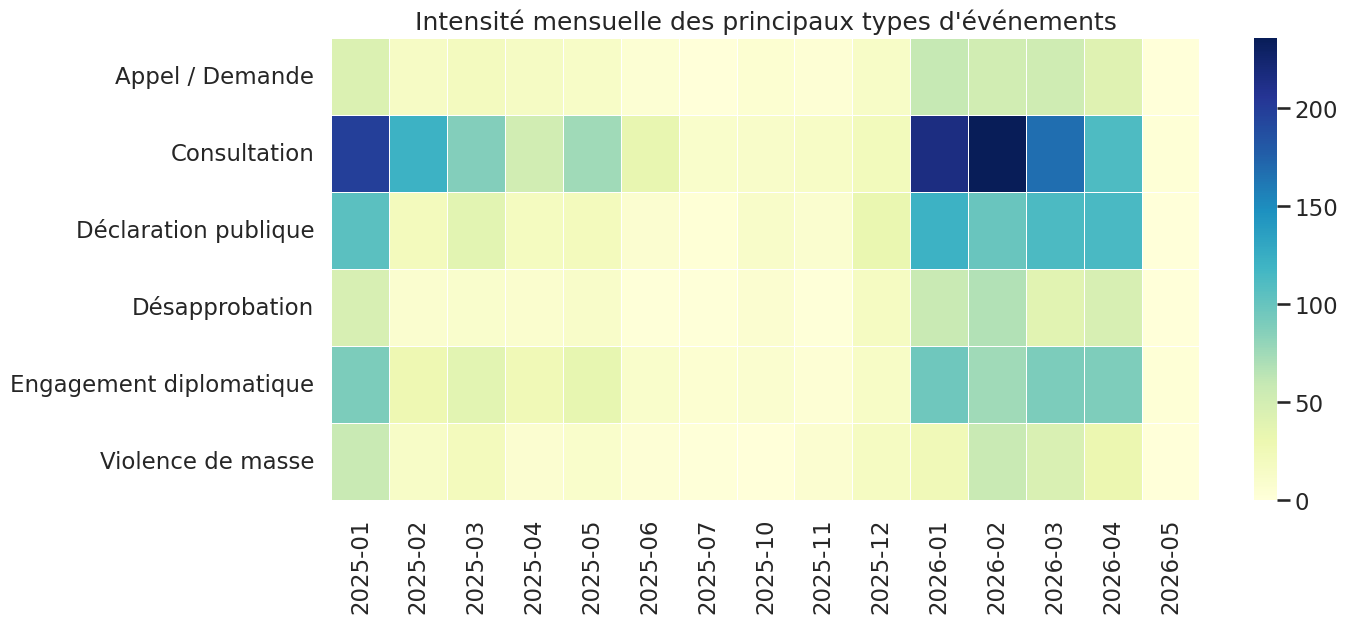

In [19]:
heatmap_data = (
    type_month_top.pivot(index="event_label", columns="year_month", values="events")
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap="YlGnBu", linewidths=0.5, ax=ax)
ax.set_title("Intensité mensuelle des principaux types d'événements")
ax.set_xlabel("")
ax.set_ylabel("")
plt.show()


## Séquence 5 — Acteurs et sources


### 5.1 Acteurs les plus visibles


On recense les acteurs les plus visibles dans le corpus.

une première hiérarchie des acteurs mentionnés.


In [20]:
actor_series = pd.concat([df["Actor1Name"], df["Actor2Name"]], ignore_index=True)
actor_series = actor_series.fillna("Inconnu").astype(str).str.strip()
actor_series = actor_series[~actor_series.isin(["", "Inconnu"])]
actor_counts = actor_series.value_counts().reset_index()
actor_counts.columns = ["actor", "events"]
actor_counts.head(12)


,actor,events
0,BENIN,2062
1,AFRICA,351
2,NIGERIA,231
3,COTONOU,176
4,GOVERNMENT,143
5,MINIST,121
6,POLICE,109
7,ECOWAS,97
8,NIGER,95
9,PRESIDENT,90


Le graphique montre les dix acteurs les plus fréquents.

lecture immédiate des acteurs dominants.


/tmp/ipykernel_54225/520267618.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=actor_counts.head(10), y="actor", x="events", palette="magma", ax=ax)


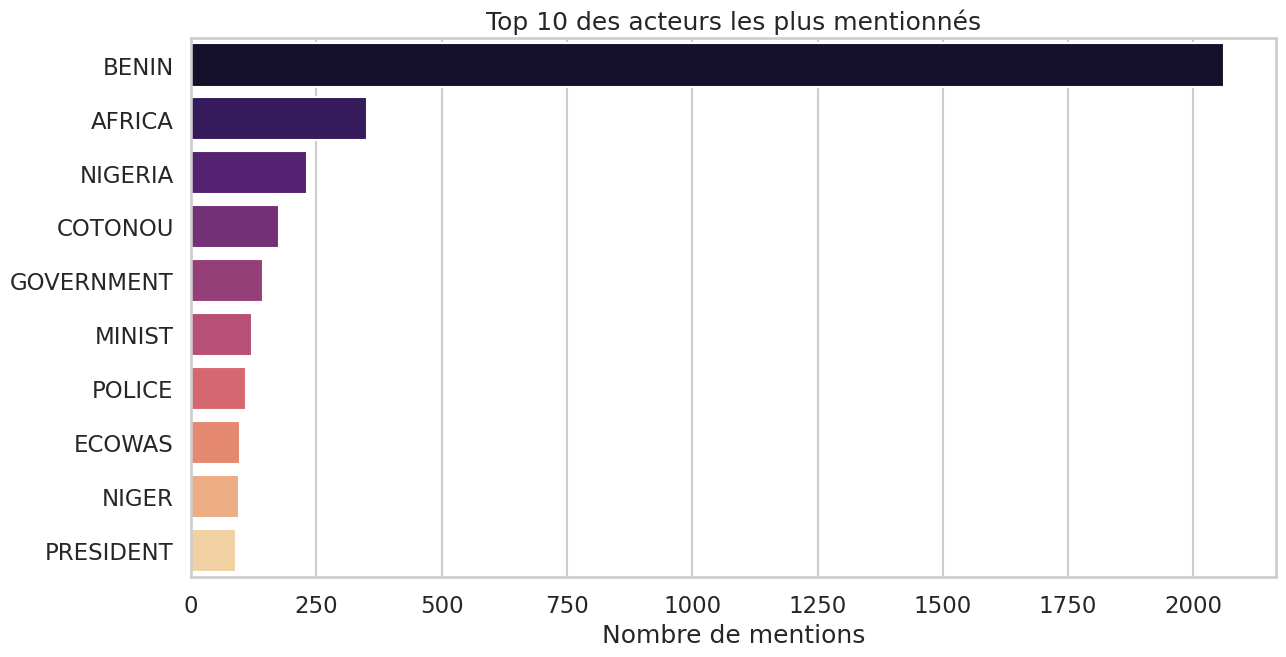

In [21]:
fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(data=actor_counts.head(10), y="actor", x="events", palette="magma", ax=ax)
ax.set_title("Top 10 des acteurs les plus mentionnés")
ax.set_xlabel("Nombre de mentions")
ax.set_ylabel("")
plt.show()


### 5.2 Sources dominantes


On recense les domaines médias les plus présents.

identification des sources les plus contributrices.


In [22]:
source_counts = df["source_domain"].value_counts().reset_index()
source_counts.columns = ["source_domain", "events"]
source_counts.head(12)


,source_domain,events
0,lanouvelletribune.info,494
1,saharareporters.com,238
2,allafrica.com,161
3,quicknews-africa.net,128
4,fr.allafrica.com,108
5,promptnewsonline.com,108
6,africatopsuccess.com,73
7,levenementprecis.com,73
8,peoplesdailyng.com,64
9,yahoo.com,59


Le graphique montre les principales sources.

poids relatif des domaines les plus actifs.


/tmp/ipykernel_54225/1242336461.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=source_counts.head(10), y="source_domain", x="events", palette="rocket", ax=ax)


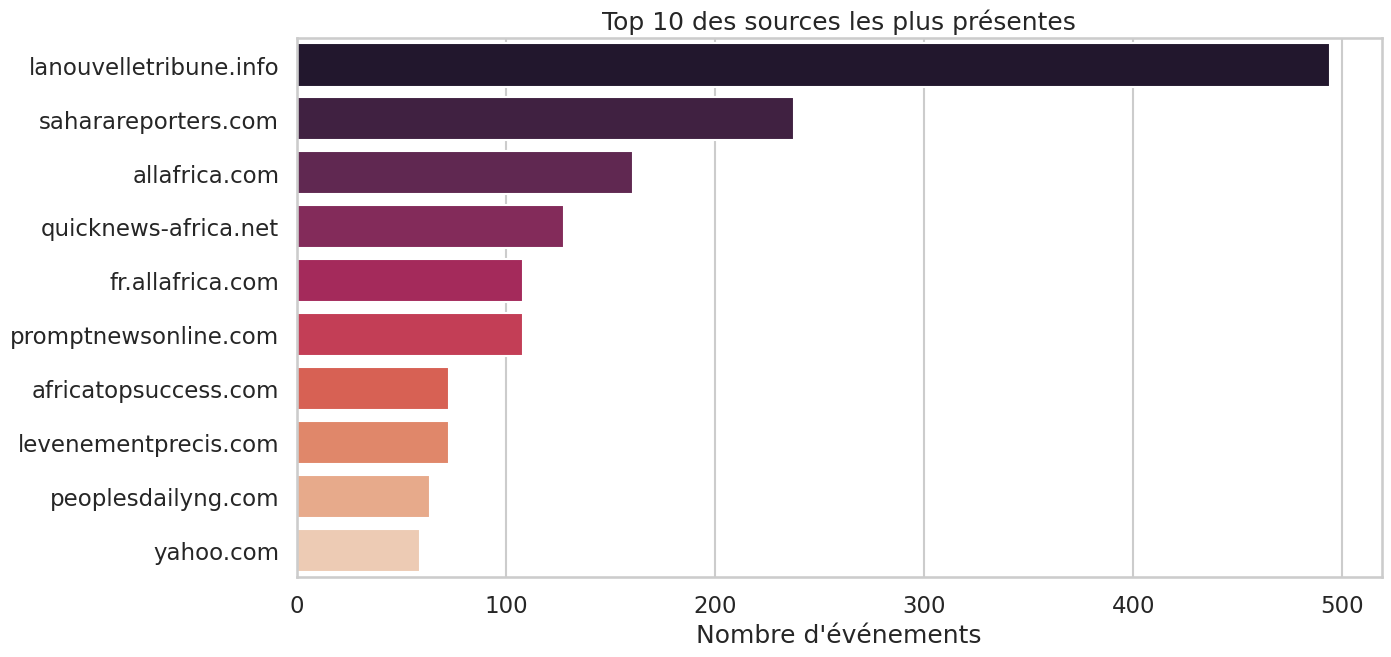

In [23]:
fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(data=source_counts.head(10), y="source_domain", x="events", palette="rocket", ax=ax)
ax.set_title("Top 10 des sources les plus présentes")
ax.set_xlabel("Nombre d'événements")
ax.set_ylabel("")
plt.show()


### 5.3 Ton moyen par source dominante


On compare la tonalité moyenne des principales sources.

premiers écarts de ton selon les médias dominants.


/tmp/ipykernel_54225/3453428916.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=source_tone, y="source_domain", x="avg_tone", palette="vlag", ax=ax)


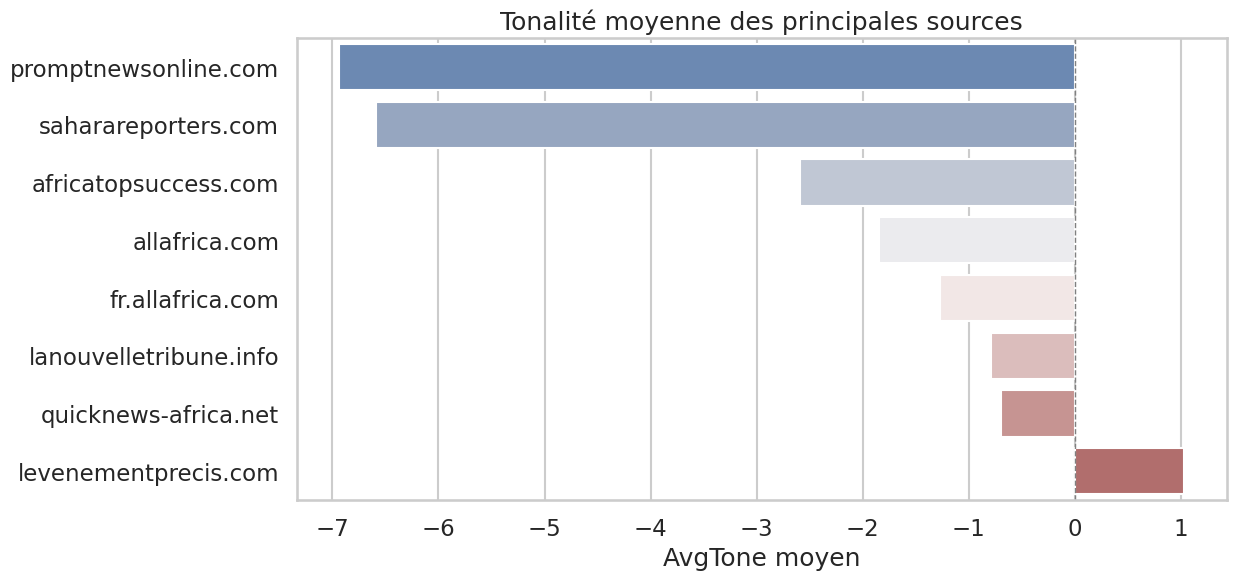

In [24]:
top_source_names = source_counts.head(8)["source_domain"].tolist()
source_tone = (
    df[df["source_domain"].isin(top_source_names)]
    .groupby("source_domain")
    .agg(events=("date", "size"), avg_tone=("AvgTone", "mean"))
    .reset_index()
    .sort_values("avg_tone")
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=source_tone, y="source_domain", x="avg_tone", palette="vlag", ax=ax)
ax.axvline(0, linestyle="--", color="gray", linewidth=1)
ax.set_title("Tonalité moyenne des principales sources")
ax.set_xlabel("AvgTone moyen")
ax.set_ylabel("")
plt.show()


## Séquence 6 — Géographie des événements


### 6.1 Localités les plus citées


On recense les localités les plus souvent citées.

une hiérarchie simple des foyers géographiques.


In [34]:
geo_counts = (
    df["ActionGeo_FullName"].fillna("Inconnu").value_counts().reset_index()
)
geo_counts.columns = ["location", "events"]
geo_counts.head(12)


,location,events
0,Benin,4370
1,"Ouidah, Atlantique, Benin",107
2,"Abomey, Zou, Benin",91
3,"Porto-Novo, Qué, Benin",48
4,"Alibori, Alibori, Benin",46
5,"Kandi, Alibori, Benin",38
6,"Karimama, Alibori, Benin",31
7,"Parakou, Borgou, Benin",28
8,"Borgou, Borgou, Benin",24
9,"Bariba, Benin (general), Benin",19


Le graphique met en avant les localités les plus présentes.

lecture rapide des zones les plus couvertes.


/tmp/ipykernel_54225/1290091117.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=geo_counts.head(10), y="location", x="events", palette="Blues_r", ax=ax)


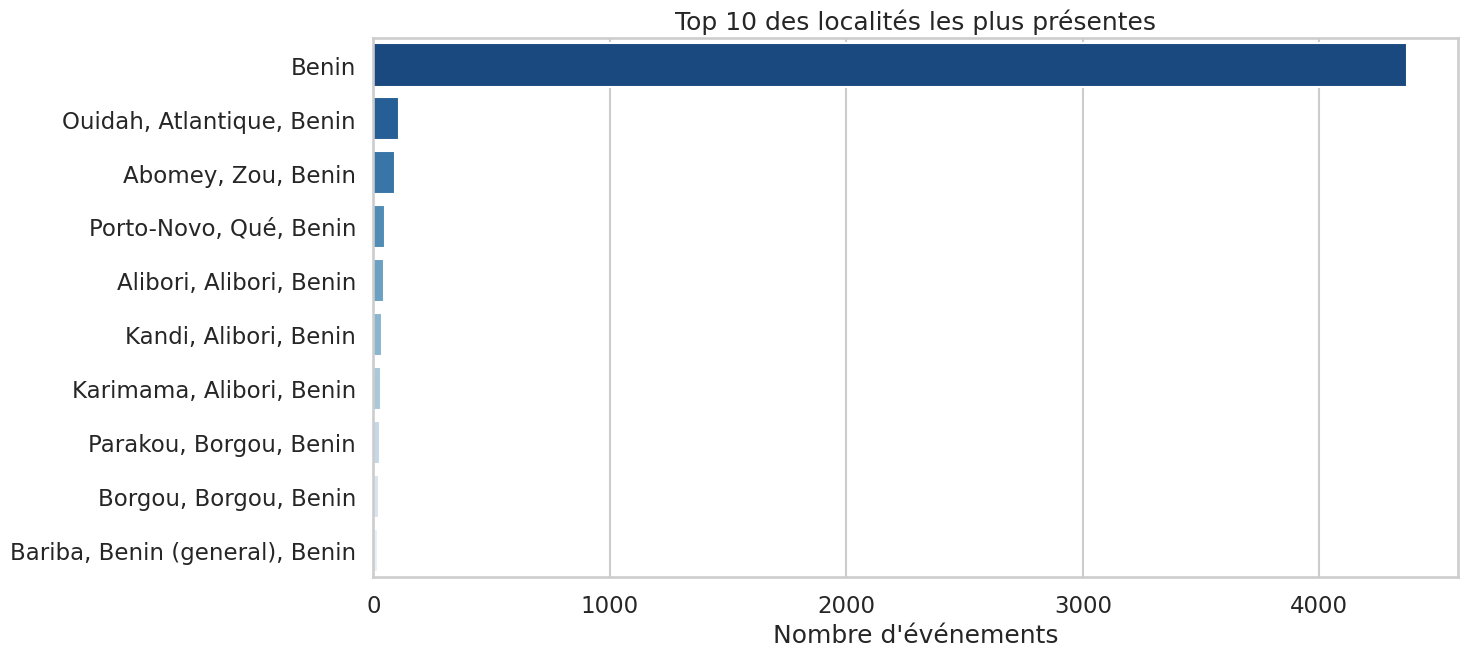

In [35]:
fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(data=geo_counts.head(10), y="location", x="events", palette="Blues_r", ax=ax)
ax.set_title("Top 10 des localités les plus présentes")
ax.set_xlabel("Nombre d'événements")
ax.set_ylabel("")
plt.show()


### 6.2 Carte simple des événements géolocalisés


Les événements géolocalisés sont replacés sur le fond du territoire béninois.

On lit mieux les zones de concentration et le contraste entre ton, volume et localisation.


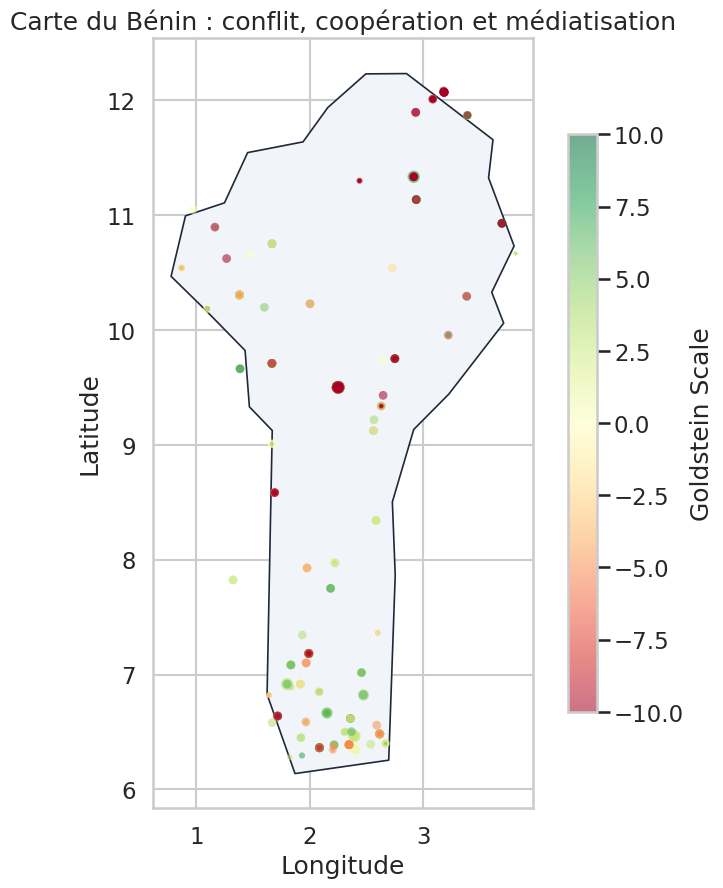

In [36]:
geo_df = df.dropna(subset=["ActionGeo_Lat", "ActionGeo_Long"]).copy()
world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")
benin = world[world["NAME"].isin(["Benin", "Bénin"])]

fig, ax = plt.subplots(figsize=(9, 10))
benin.plot(ax=ax, color="#f1f5f9", edgecolor="#1f2937", linewidth=1.2)

scatter = ax.scatter(
    geo_df["ActionGeo_Long"],
    geo_df["ActionGeo_Lat"],
    c=geo_df["GoldsteinScale"],
    s=geo_df["NumArticles"].fillna(1) * 4,
    cmap="RdYlGn",
    alpha=0.55,
    edgecolors="none",
)

cbar = plt.colorbar(scatter, ax=ax, shrink=0.75)
cbar.set_label("Goldstein Scale")
ax.set_title("Carte du Bénin : conflit, coopération et médiatisation")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()


## Séquence 7 — Anomalies et signaux clés


### 7.1 Mois atypiques en volume


On applique une règle simple pour repérer les mois atypiques.

un premier marquage statistique des anomalies de volume.


In [37]:
q1 = monthly["events"].quantile(0.25)
q3 = monthly["events"].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
lower_bound = max(q1 - 1.5 * iqr, 0)

monthly["is_volume_anomaly"] = (monthly["events"] > upper_bound) | (monthly["events"] < lower_bound)
monthly[["year_month", "events", "is_volume_anomaly"]]


,year_month,events,is_volume_anomaly
0,2025-01,705,False
1,2025-02,293,False
2,2025-03,322,False
3,2025-04,171,False
4,2025-05,219,False
5,2025-06,75,False
6,2025-07,25,False
7,2025-10,57,False
8,2025-11,73,False
9,2025-12,173,False


Le graphique montre les mois atypiques repérés sur le volume.

lecture claire des mois hors norme selon cette règle.


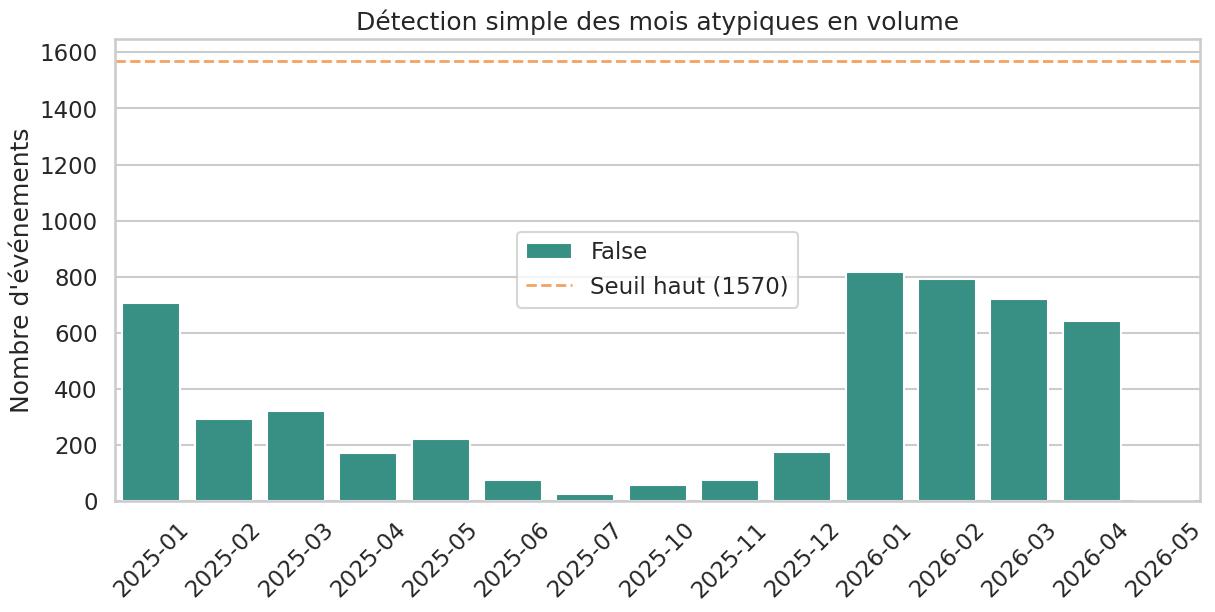

In [38]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(
    data=monthly,
    x="year_month",
    y="events",
    hue="is_volume_anomaly",
    palette={False: "#2a9d8f", True: "#e63946"},
    dodge=False,
    ax=ax,
)
ax.axhline(upper_bound, linestyle="--", color="#f4a261", linewidth=2, label=f"Seuil haut ({upper_bound:.0f})")
ax.set_title("Détection simple des mois atypiques en volume")
ax.set_xlabel("")
ax.set_ylabel("Nombre d'événements")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.show()


### 7.2 Mois les plus tendus


On isole les mois les plus tendus selon le ton et la part négative.

repérage des fenêtres les plus défavorables.


In [39]:
monthly["negative_share"] = (
    df.assign(is_negative=df["AvgTone"] < 0)
    .groupby("year_month")["is_negative"]
    .mean()
    .reindex(monthly["year_month"])
    .values
)

monthly.sort_values(["avg_tone", "events"]).head(8)


,year_month,events,avg_tone,avg_goldstein,avg_articles,mom_change_pct,is_volume_anomaly,negative_share
9,2025-12,173,-2.773172,-0.758382,7.884393,136.986301,False,0.890173
14,2026-05,8,-2.541334,0.187500,5.500000,-98.750000,False,0.875000
11,2026-02,791,-2.063033,0.147661,6.573957,-3.182375,False,0.627054
13,2026-04,640,-1.758595,0.505312,6.401562,-11.111111,False,0.639062
10,2026-01,817,-1.587441,0.789718,6.920441,372.254335,False,0.578947
1,2025-02,293,-1.380411,0.869625,7.641638,-58.439716,False,0.641638
12,2026-03,720,-1.368964,0.433750,7.075000,-8.975980,False,0.588889
2,2025-03,322,-1.162040,0.808075,7.618012,9.897611,False,0.506211


On compare visuellement les mois les plus négatifs.

hiérarchie des périodes médiatiquement les plus dures.


/tmp/ipykernel_54225/4229645193.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly.sort_values("avg_tone").head(6), y="year_month", x="avg_tone", palette="flare", ax=axes[0])
/tmp/ipykernel_54225/4229645193.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly.sort_values("negative_share", ascending=False).head(6), y="year_month", x="negative_share", palette="crest", ax=axes[1])


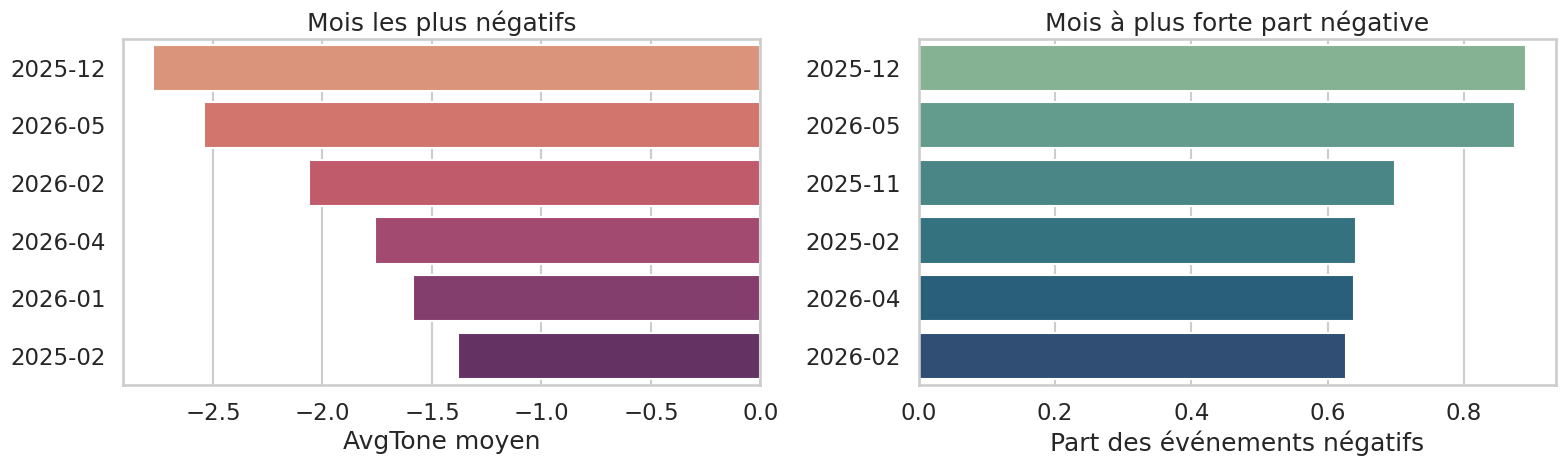

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=monthly.sort_values("avg_tone").head(6), y="year_month", x="avg_tone", palette="flare", ax=axes[0])
axes[0].set_title("Mois les plus négatifs")
axes[0].set_xlabel("AvgTone moyen")
axes[0].set_ylabel("")

sns.barplot(data=monthly.sort_values("negative_share", ascending=False).head(6), y="year_month", x="negative_share", palette="crest", ax=axes[1])
axes[1].set_title("Mois à plus forte part négative")
axes[1].set_xlabel("Part des événements négatifs")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()


### 7.3 Lecture finale


On termine par une synthèse des constats principaux.

une base directe pour les insights de restitution.


In [32]:
key_findings = pd.DataFrame({
    "axe": [
        "Volume",
        "Type dominant",
        "Acteur dominant",
        "Source dominante",
        "Mois le plus tendu",
        "Mois le plus dense",
    ],
    "constat": [
        f"{len(df):,} événements observés sur la période.",
        f"{type_counts.iloc[0]['event_label']} est le type le plus fréquent.",
        f"{actor_counts.iloc[0]['actor']} est l'acteur le plus visible.",
        f"{source_counts.iloc[0]['source_domain']} est la source la plus présente.",
        f"{monthly.sort_values('avg_tone').iloc[0]['year_month']} présente le ton moyen le plus négatif.",
        f"{monthly.sort_values('events', ascending=False).iloc[0]['year_month']} concentre le plus grand volume.",
    ]
})
key_findings


,axe,constat
0,Volume,"5,089 événements observés sur la période."
1,Type dominant,Consultation est le type le plus fréquent.
2,Acteur dominant,BENIN est l'acteur le plus visible.
3,Source dominante,lanouvelletribune.info est la source la plus p...
4,Mois le plus tendu,2025-12 présente le ton moyen le plus négatif.
5,Mois le plus dense,2026-01 concentre le plus grand volume.
